# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [1]:
import sys
import os

# Pfad anpassen, um utils_notebook und das eval-Modul zu importieren
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Alle modularisierten Funktionen importieren
from utils_notebook.compare import compare_wunden_interactive
from utils_notebook.category_compare import compare_categories_interactive
from utils_notebook.wundbild import zeige_wundbild_interactive
from utils_notebook.metrics_explorer import calculate_scores, display_scores_interactive, calculate_summary, display_summary
from utils_notebook.plot_compare import plot_gt_comparison

# Pfade definieren (Start mit rohem GT)
CSV_PATH = "../../data/ground_truth/lohmann_rauscher/Experte2_LR_GroundTruth.csv"
JSON_DIR = "../data/llm_outputs/zero_shot/zero_shot_raw/zero_shot_raw.csv"


In [2]:
# =====================================================================
# 1. INTERAKTIVER DETAILVERGLEICH PRO WUNDBILD
# =====================================================================
compare_wunden_interactive(CSV_PATH, JSON_DIR)


LLM output path does not exist: ../data/llm_outputs/zero_shot/zero_shot_raw/zero_shot_raw.csv


Keine übereinstimmenden Wundbilder (image_ids) gefunden.


In [3]:
# =====================================================================
# 2. INTERAKTIVER KATEGORIE-VERGLEICH ALLER WUNDEN
# =====================================================================
compare_categories_interactive(CSV_PATH, JSON_DIR)

Erfolgreich 20 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Spezifizierung', 'Lokalisation',…

In [4]:
# =====================================================================
# 3. INTERAKTIVE WUNDBILD-ANZEIGE
# =====================================================================
zeige_wundbild_interactive()

interactive(children=(BoundedIntText(value=1, description='Wund-Nummer:', max=50, min=1, style=DescriptionStyl…

In [5]:
# =====================================================================
# 4. METRIKEN-EXPLORER (DETAIL-SCORES PRO WUNDBILD)
# =====================================================================
# raw=True deaktiviert alle on-the-fly Mappings und Bereinigungen
df_scores_raw = calculate_scores(CSV_PATH, JSON_DIR, raw=True)

display_scores_interactive(df_scores_raw)
df_summary_raw = calculate_summary(df_scores_raw)
display_summary(df_summary_raw)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
antimikrobielles_agens,checklist,30.0%,30.0%
debridement,checklist,0.0%,0.0%
hautschutz,checklist,39.2%,30.0%
kompression_produkte,checklist,85.0%,85.0%
sekundaerverband,checklist,5.0%,5.0%
wundrand,checklist,79.8%,50.0%
wundstadium,checklist,75.8%,45.0%
wundumgebung,checklist,55.3%,25.0%
primaerverband,checklist (best path),57.5%,15.0%
lokalisation,decode,0.0%,0.0%


## Phase 2

In [6]:
# =====================================================================
# GROUND TRUTH NORMALISIERUNG
# =====================================================================
CSV_PATH_NORM = "../data/ground_truth/allgemeine_verbandsklassen_normalised.csv"
LLM_PATH_NORM = "../data/llm_outputs/zero_shot/zero_shot_normalised/zero_shot_normalised.csv"
CSV_PATH = CSV_PATH_NORM
LLM_PATH = LLM_PATH_NORM

In [7]:
compare_wunden_interactive(CSV_PATH_NORM, LLM_PATH_NORM)
compare_categories_interactive(CSV_PATH_NORM, LLM_PATH_NORM)

Erfolgreich 20 Wundbilder zum Vergleich geladen.


interactive(children=(Dropdown(description='Wundbild:', options=('wunde_01', 'wunde_02', 'wunde_03', 'wunde_04…

Erfolgreich 20 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Spezifizierung', 'Lokalisation',…

In [8]:
# =====================================================================
# METRIKEN FÜR DAS NORMALISIERTE GT BERECHNEN UND ANZEIGEN
# =====================================================================
# raw=False aktiviert spelling_mapping und category_decoding
df_scores_norm = calculate_scores(CSV_PATH, JSON_DIR, raw=False)

display_scores_interactive(df_scores_norm)
df_summary_norm = calculate_summary(df_scores_norm)
display_summary(df_summary_norm)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
antimikrobielles_agens,checklist,77.5%,65.0%
debridement,checklist,0.0%,0.0%
hautschutz,checklist,39.2%,30.0%
kompression_produkte,checklist,85.0%,85.0%
sekundaerverband,checklist,5.0%,5.0%
wundrand,checklist,79.8%,50.0%
wundstadium,checklist,75.8%,45.0%
wundumgebung,checklist,55.3%,25.0%
primaerverband,checklist (best path),57.5%,15.0%
lokalisation,decode,81.7%,75.0%


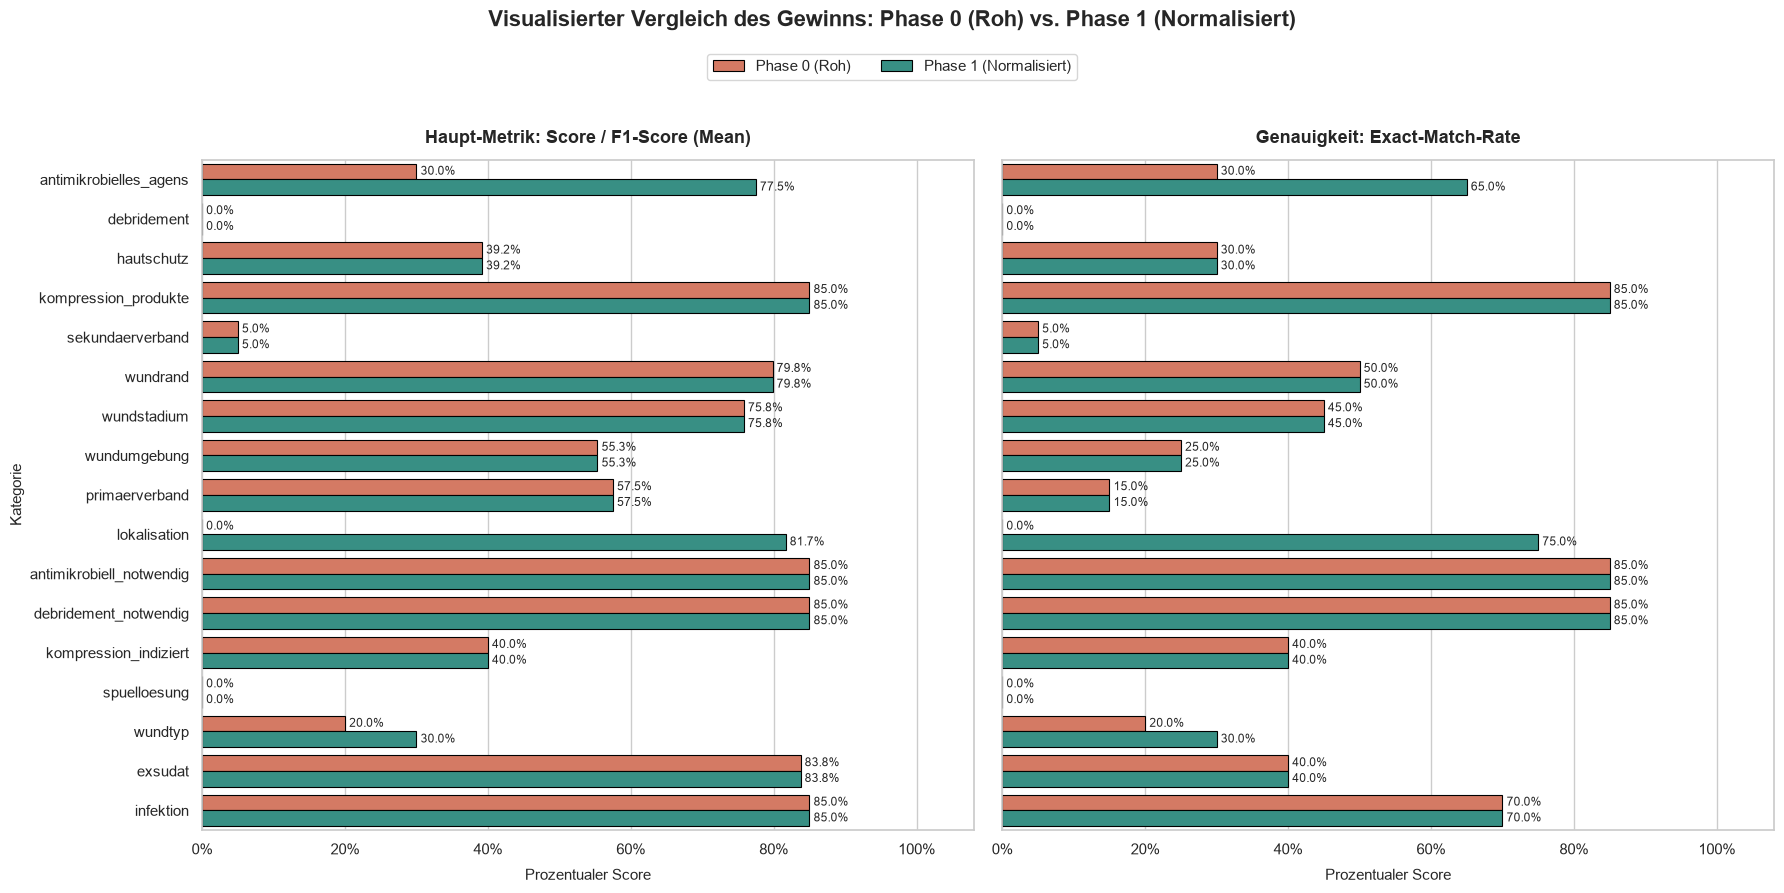

In [9]:
# Vergleicht grafisch Phase 0 und Phase 1 nebeneinander
plot_gt_comparison(df_summary_raw, df_summary_norm)
